### B1 Pipeline : Technical Indicators Only

In [1]:
import polars as pl
import numpy as np
import os, joblib, pickle
from datetime import date
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from xgboost import XGBClassifier, XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score, roc_auc_score,
    mean_absolute_error, mean_squared_error, r2_score, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay,
)
import matplotlib.pyplot as plt

In [2]:
Model_path = "../data/model_staging/tech_modeling_table.parquet"

df_model = pl.read_parquet(Model_path)
print(f"Shape: {df_model.shape}")
print(f"Target direction distribution:\n{df_model['target_class'].value_counts().sort('target_class')}")

Shape: (24048, 239)
Target direction distribution:
shape: (3, 2)
┌──────────────┬───────┐
│ target_class ┆ count │
│ ---          ┆ ---   │
│ i64          ┆ u32   │
╞══════════════╪═══════╡
│ 0            ┆ 7955  │
│ 1            ┆ 6428  │
│ 2            ┆ 9665  │
└──────────────┴───────┘


In [3]:
# ── Add year/quarter for expanding-window folds ──────────────
df_model = df_model.with_columns([
    pl.col("earnings_date").dt.year().alias("year"),
    pl.col("earnings_date").dt.quarter().alias("quarter"),
])
df_model = df_model.filter(pl.col("year") <= 2025)

INITIAL_TRAIN_YEARS = 7
EXCLUDE_COLS = [
    "symbol", "earnings_date", "entry_price", "target_return",
    "target_class", "max_high", "min_high", "max_day", "min_day",
    "car_3day", "car_t2_t10",
]
feature_cols = [c for c in df_model.columns if c not in EXCLUDE_COLS]
print(f"Total features: {len(feature_cols)}")

unique_quarters = df_model.select(["year", "quarter"]).unique().sort(["year", "quarter"])
quarters_list = unique_quarters.to_dicts()

earliest_year = quarters_list[0]["year"]
initial_train_end_year = earliest_year + INITIAL_TRAIN_YEARS - 1
first_test_idx = next(i for i, q in enumerate(quarters_list) if q["year"] > initial_train_end_year)

print(f"Initial training: {earliest_year}–{initial_train_end_year} ({INITIAL_TRAIN_YEARS} yrs)")
print(f"First test: {quarters_list[first_test_idx]}")

folds_data = []
fold_num = 1

for test_quarter_idx in range(first_test_idx, len(quarters_list)):
    test_q = quarters_list[test_quarter_idx]
    val_q  = quarters_list[test_quarter_idx - 1]
    test_label = f"{test_q['year']}_Q{test_q['quarter']}"

    test_data = df_model.filter(
        (pl.col("year") == test_q["year"]) & (pl.col("quarter") == test_q["quarter"])
    )
    train_data = df_model.filter(
        (pl.col("year") < val_q["year"]) |
        ((pl.col("year") == val_q["year"]) & (pl.col("quarter") < val_q["quarter"]))
    )

    if len(train_data) == 0 or len(test_data) == 0:
        continue

    X_train = train_data.select(feature_cols).to_numpy()
    X_test  = test_data.select(feature_cols).to_numpy()

    X_train = np.where(np.isinf(X_train), np.nan, X_train)
    X_test  = np.where(np.isinf(X_test),  np.nan, X_test)

    imputer = SimpleImputer(strategy="median")
    X_train = imputer.fit_transform(X_train)
    X_test  = imputer.transform(X_test)

    scaler     = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc  = scaler.transform(X_test)

    folds_data.append({
        "fold_num":    fold_num,
        "test_quarter": test_label,
        "test_year":   test_q["year"],
        "X_train":     X_train,    "X_test":     X_test,
        "X_train_sc":  X_train_sc, "X_test_sc":  X_test_sc,
        "y_train_cls": train_data["target_class"].to_numpy(),
        "y_test_cls":  test_data["target_class"].to_numpy(),
        "y_train_ret": train_data["target_return"].to_numpy(),
        "y_test_ret":  test_data["target_return"].to_numpy(),
    })

    print(f"Fold {fold_num:2d} [{test_label}]:  "
          f"train={X_train.shape[0]:6,}  "
          f"test={X_test.shape[0]:4,}")

    fold_num += 1

print(f"\nTotal folds: {len(folds_data)}")

# For fold-across-year comparison charts
fold_years = [f["test_year"] for f in folds_data]


Total features: 230
Initial training: 2014–2020 (7 yrs)
First test: {'year': 2021, 'quarter': 1}
Fold  1 [2021_Q1]:  train=12,683  test= 492
Fold  2 [2021_Q2]:  train=13,169  test= 493
Fold  3 [2021_Q3]:  train=13,661  test= 493
Fold  4 [2021_Q4]:  train=14,154  test= 492
Fold  5 [2022_Q1]:  train=14,647  test= 494
Fold  6 [2022_Q2]:  train=15,139  test= 495
Fold  7 [2022_Q3]:  train=15,633  test= 493
Fold  8 [2022_Q4]:  train=16,128  test= 493
Fold  9 [2023_Q1]:  train=16,621  test= 492
Fold 10 [2023_Q2]:  train=17,114  test= 498
Fold 11 [2023_Q3]:  train=17,606  test= 496
Fold 12 [2023_Q4]:  train=18,104  test= 498
Fold 13 [2024_Q1]:  train=18,600  test= 496
Fold 14 [2024_Q2]:  train=19,098  test= 501
Fold 15 [2024_Q3]:  train=19,594  test= 499
Fold 16 [2024_Q4]:  train=20,095  test= 504
Fold 17 [2025_Q1]:  train=20,594  test= 502
Fold 18 [2025_Q2]:  train=21,098  test= 501
Fold 19 [2025_Q3]:  train=21,600  test= 502
Fold 20 [2025_Q4]:  train=22,101  test= 503

Total folds: 20


In [4]:
np.random.seed(42)

b0_clf = {"fold_acc": [], "preds": [], "true": []}
b0_reg = {"fold_mae": [], "fold_rmse": [], "preds": [], "true": []}

for f in folds_data:
    preds_cls = np.random.randint(0, 3, size=len(f["y_test_cls"]))
    acc = accuracy_score(f["y_test_cls"], preds_cls)
    b0_clf["fold_acc"].append(acc)
    b0_clf["preds"].extend(preds_cls)
    b0_clf["true"].extend(f["y_test_cls"])

    preds_ret = np.full(len(f["y_test_ret"]), f["y_train_ret"].mean())
    b0_reg["fold_mae"].append(mean_absolute_error(f["y_test_ret"], preds_ret))
    b0_reg["fold_rmse"].append(np.sqrt(mean_squared_error(f["y_test_ret"], preds_ret)))
    b0_reg["preds"].extend(preds_ret)
    b0_reg["true"].extend(f["y_test_ret"])

    print(f"Fold {f['fold_num']}: DA={acc:.4f}")

print(f"\nAvg DA:   {np.mean(b0_clf['fold_acc']):.4f}")
print(f"Avg MAE:  {np.mean(b0_reg['fold_mae']):.4f}")
print(f"Avg RMSE: {np.mean(b0_reg['fold_rmse']):.4f}")

Fold 1: DA=0.3252
Fold 2: DA=0.3448
Fold 3: DA=0.2961
Fold 4: DA=0.3293
Fold 5: DA=0.3036
Fold 6: DA=0.3515
Fold 7: DA=0.3428
Fold 8: DA=0.3266
Fold 9: DA=0.3110
Fold 10: DA=0.3012
Fold 11: DA=0.3125
Fold 12: DA=0.3434
Fold 13: DA=0.3468
Fold 14: DA=0.3553
Fold 15: DA=0.3367
Fold 16: DA=0.3829
Fold 17: DA=0.3785
Fold 18: DA=0.3293
Fold 19: DA=0.3108
Fold 20: DA=0.3181

Avg DA:   0.3323
Avg MAE:  0.0306
Avg RMSE: 0.0450


In [5]:
lr_clf = {"fold_acc": [], "preds": [], "probs": [], "true": []}
lr_model = LogisticRegression(max_iter=1000, class_weight="balanced")

for f in folds_data:
    lr_model.fit(f["X_train_sc"], f["y_train_cls"])
    preds = lr_model.predict(f["X_test_sc"])
    probs = lr_model.predict_proba(f["X_test_sc"])

    acc = accuracy_score(f["y_test_cls"], preds)
    lr_clf["fold_acc"].append(acc)
    lr_clf["preds"].extend(preds)
    lr_clf["probs"].extend(probs)
    lr_clf["true"].extend(f["y_test_cls"])

    print(f"Fold {f['fold_num']} [{f['test_quarter']}]: DA={acc:.4f}")

true = np.array(lr_clf["true"])
preds = np.array(lr_clf["preds"])
print(f"\nAvg DA:     {np.mean(lr_clf['fold_acc']):.4f}")
print(f"Pooled F1:  {f1_score(true, preds, average='weighted'):.4f}")
print(f"Precision:  {precision_score(true, preds, average='weighted'):.4f}")
print(f"Recall:     {recall_score(true, preds, average='weighted'):.4f}")
print(f"Pooled AUC: {roc_auc_score(true, np.array(lr_clf['probs']), multi_class='ovr', average='weighted'):.4f}")

Fold 1 [2021_Q1]: DA=0.5183
Fold 2 [2021_Q2]: DA=0.3509
Fold 3 [2021_Q3]: DA=0.3834
Fold 4 [2021_Q4]: DA=0.4187
Fold 5 [2022_Q1]: DA=0.4818
Fold 6 [2022_Q2]: DA=0.3495
Fold 7 [2022_Q3]: DA=0.5396
Fold 8 [2022_Q4]: DA=0.6795
Fold 9 [2023_Q1]: DA=0.4126
Fold 10 [2023_Q2]: DA=0.3956
Fold 11 [2023_Q3]: DA=0.4113
Fold 12 [2023_Q4]: DA=0.4337
Fold 13 [2024_Q1]: DA=0.3246
Fold 14 [2024_Q2]: DA=0.3553
Fold 15 [2024_Q3]: DA=0.4208
Fold 16 [2024_Q4]: DA=0.4286
Fold 17 [2025_Q1]: DA=0.3665
Fold 18 [2025_Q2]: DA=0.5848
Fold 19 [2025_Q3]: DA=0.4263
Fold 20 [2025_Q4]: DA=0.4056

Avg DA:     0.4344
Pooled F1:  0.4278
Precision:  0.4239
Recall:     0.4342
Pooled AUC: 0.5972


In [6]:
linreg = {"fold_mae": [], "fold_rmse": [], "preds": [], "true": []}
linreg_model = LinearRegression()

for f in folds_data:
    linreg_model.fit(f["X_train_sc"], f["y_train_ret"])
    preds = linreg_model.predict(f["X_test_sc"])

    mae = mean_absolute_error(f["y_test_ret"], preds)
    rmse = np.sqrt(mean_squared_error(f["y_test_ret"], preds))
    linreg["fold_mae"].append(mae)
    linreg["fold_rmse"].append(rmse)
    linreg["preds"].extend(preds)
    linreg["true"].extend(f["y_test_ret"])

    print(f"Fold {f['fold_num']} [{f['test_quarter']}]: MAE={mae:.4f}  RMSE={rmse:.4f}")

print(f"\nAvg MAE:   {np.mean(linreg['fold_mae']):.4f}")
print(f"Avg RMSE:  {np.mean(linreg['fold_rmse']):.4f}")
print(f"Pooled R²: {r2_score(np.array(linreg['true']), np.array(linreg['preds'])):.4f}")

Fold 1 [2021_Q1]: MAE=0.0357  RMSE=0.0506
Fold 2 [2021_Q2]: MAE=0.0263  RMSE=0.0372
Fold 3 [2021_Q3]: MAE=0.0246  RMSE=0.0336
Fold 4 [2021_Q4]: MAE=0.0262  RMSE=0.0378
Fold 5 [2022_Q1]: MAE=0.0362  RMSE=0.0522
Fold 6 [2022_Q2]: MAE=0.0479  RMSE=0.0574
Fold 7 [2022_Q3]: MAE=0.0275  RMSE=0.0353
Fold 8 [2022_Q4]: MAE=0.0381  RMSE=0.0541
Fold 9 [2023_Q1]: MAE=0.0246  RMSE=0.0338
Fold 10 [2023_Q2]: MAE=0.0242  RMSE=0.0372
Fold 11 [2023_Q3]: MAE=0.0219  RMSE=0.0339
Fold 12 [2023_Q4]: MAE=0.0310  RMSE=0.0415
Fold 13 [2024_Q1]: MAE=0.0298  RMSE=0.0457
Fold 14 [2024_Q2]: MAE=0.0280  RMSE=0.0436
Fold 15 [2024_Q3]: MAE=0.0298  RMSE=0.0491
Fold 16 [2024_Q4]: MAE=0.0336  RMSE=0.0567
Fold 17 [2025_Q1]: MAE=0.0260  RMSE=0.0366
Fold 18 [2025_Q2]: MAE=0.0373  RMSE=0.0577
Fold 19 [2025_Q3]: MAE=0.0257  RMSE=0.0377
Fold 20 [2025_Q4]: MAE=0.0302  RMSE=0.0402

Avg MAE:   0.0302
Avg RMSE:  0.0436
Pooled R²: 0.0580


In [7]:
rf_clf = {"fold_acc": [], "preds": [], "probs": [], "true": []}
rf_clf_model = RandomForestClassifier(n_estimators=50, max_depth=10, class_weight="balanced", random_state=42, n_jobs=-1)

for f in folds_data:
    rf_clf_model.fit(f["X_train"], f["y_train_cls"])
    preds = rf_clf_model.predict(f["X_test"])
    probs = rf_clf_model.predict_proba(f["X_test"])

    acc = accuracy_score(f["y_test_cls"], preds)
    rf_clf["fold_acc"].append(acc)
    rf_clf["preds"].extend(preds)
    rf_clf["probs"].extend(probs)
    rf_clf["true"].extend(f["y_test_cls"])

    print(f"Fold {f['fold_num']} [{f['test_quarter']}]: DA={acc:.4f}")

true = np.array(rf_clf["true"])
preds = np.array(rf_clf["preds"])
print(f"\nAvg DA:     {np.mean(rf_clf['fold_acc']):.4f}")
print(f"Pooled F1:  {f1_score(true, preds, average='weighted'):.4f}")
print(f"Precision:  {precision_score(true, preds, average='weighted'):.4f}")
print(f"Recall:     {recall_score(true, preds, average='weighted'):.4f}")
print(f"Pooled AUC: {roc_auc_score(true, np.array(rf_clf['probs']), multi_class='ovr', average='weighted'):.4f}")

Fold 1 [2021_Q1]: DA=0.5732
Fold 2 [2021_Q2]: DA=0.4584
Fold 3 [2021_Q3]: DA=0.3935
Fold 4 [2021_Q4]: DA=0.4431
Fold 5 [2022_Q1]: DA=0.4798
Fold 6 [2022_Q2]: DA=0.3475
Fold 7 [2022_Q3]: DA=0.5659
Fold 8 [2022_Q4]: DA=0.6775
Fold 9 [2023_Q1]: DA=0.3780
Fold 10 [2023_Q2]: DA=0.3635
Fold 11 [2023_Q3]: DA=0.4294
Fold 12 [2023_Q4]: DA=0.5301
Fold 13 [2024_Q1]: DA=0.3690
Fold 14 [2024_Q2]: DA=0.4271
Fold 15 [2024_Q3]: DA=0.4008
Fold 16 [2024_Q4]: DA=0.4028
Fold 17 [2025_Q1]: DA=0.3526
Fold 18 [2025_Q2]: DA=0.6208
Fold 19 [2025_Q3]: DA=0.4084
Fold 20 [2025_Q4]: DA=0.3897

Avg DA:     0.4505
Pooled F1:  0.4170
Precision:  0.4191
Recall:     0.4503
Pooled AUC: 0.6004


In [8]:
rf_reg = {"fold_mae": [], "fold_rmse": [], "fold_r2": [], "preds": [], "true": []}
rf_reg_model = XGBRegressor(n_estimators=50, max_depth=6, random_state=42, n_jobs=-1)

for f in folds_data:
    rf_reg_model.fit(f["X_train"], f["y_train_ret"])
    preds = rf_reg_model.predict(f["X_test"])

    mae = mean_absolute_error(f["y_test_ret"], preds)
    rmse = np.sqrt(mean_squared_error(f["y_test_ret"], preds))
    r2 = r2_score(f["y_test_ret"], preds)
    rf_reg["fold_mae"].append(mae)
    rf_reg["fold_rmse"].append(rmse)
    rf_reg["fold_r2"].append(r2)
    rf_reg["preds"].extend(preds)
    rf_reg["true"].extend(f["y_test_ret"])

    print(f"Fold {f['fold_num']} [{f['test_quarter']}]: MAE={mae:.4f}  RMSE={rmse:.4f}  R²={r2:.4f}")

print(f"\nAvg MAE:   {np.mean(rf_reg['fold_mae']):.4f}")
print(f"Avg RMSE:  {np.mean(rf_reg['fold_rmse']):.4f}")
print(f"Avg R²:    {np.mean(rf_reg['fold_r2']):.4f}")
print(f"Pooled R²: {r2_score(np.array(rf_reg['true']), np.array(rf_reg['preds'])):.4f}")

Fold 1 [2021_Q1]: MAE=0.0373  RMSE=0.0513  R²=0.0511
Fold 2 [2021_Q2]: MAE=0.0271  RMSE=0.0377  R²=-0.0703
Fold 3 [2021_Q3]: MAE=0.0245  RMSE=0.0331  R²=0.0611
Fold 4 [2021_Q4]: MAE=0.0271  RMSE=0.0398  R²=-0.0564
Fold 5 [2022_Q1]: MAE=0.0386  RMSE=0.0538  R²=-0.0144
Fold 6 [2022_Q2]: MAE=0.0457  RMSE=0.0579  R²=-0.8362
Fold 7 [2022_Q3]: MAE=0.0333  RMSE=0.0434  R²=-0.3352
Fold 8 [2022_Q4]: MAE=0.0391  RMSE=0.0525  R²=0.1535
Fold 9 [2023_Q1]: MAE=0.0263  RMSE=0.0364  R²=0.0043
Fold 10 [2023_Q2]: MAE=0.0241  RMSE=0.0391  R²=0.1443
Fold 11 [2023_Q3]: MAE=0.0212  RMSE=0.0383  R²=-0.5946
Fold 12 [2023_Q4]: MAE=0.0334  RMSE=0.0439  R²=-0.1330
Fold 13 [2024_Q1]: MAE=0.0274  RMSE=0.0422  R²=0.1732
Fold 14 [2024_Q2]: MAE=0.0274  RMSE=0.0417  R²=0.0819
Fold 15 [2024_Q3]: MAE=0.0291  RMSE=0.0395  R²=0.0372
Fold 16 [2024_Q4]: MAE=0.0349  RMSE=0.0570  R²=0.1283
Fold 17 [2025_Q1]: MAE=0.0320  RMSE=0.0461  R²=-0.7686
Fold 18 [2025_Q2]: MAE=0.0370  RMSE=0.0547  R²=0.1762
Fold 19 [2025_Q3]: MAE=0.0267

In [9]:
xgb_clf = {"fold_acc": [], "preds": [], "probs": [], "true": []}
xgb_clf_model = XGBClassifier(n_estimators=200, eval_metric="logloss", random_state=42)

for f in folds_data:
    xgb_clf_model.fit(f["X_train"], f["y_train_cls"])
    preds = xgb_clf_model.predict(f["X_test"])
    probs = xgb_clf_model.predict_proba(f["X_test"])

    acc = accuracy_score(f["y_test_cls"], preds)
    xgb_clf["fold_acc"].append(acc)
    xgb_clf["preds"].extend(preds)
    xgb_clf["probs"].extend(probs)
    xgb_clf["true"].extend(f["y_test_cls"])

    print(f"Fold {f['fold_num']} [{f['test_quarter']}]: DA={acc:.4f}")

true = np.array(xgb_clf["true"])
preds = np.array(xgb_clf["preds"])
print(f"\nAvg DA:     {np.mean(xgb_clf['fold_acc']):.4f}")
print(f"Pooled F1:  {f1_score(true, preds, average='weighted'):.4f}")
print(f"Precision:  {precision_score(true, preds, average='weighted'):.4f}")
print(f"Recall:     {recall_score(true, preds, average='weighted'):.4f}")
print(f"Pooled AUC: {roc_auc_score(true, np.array(xgb_clf['probs']), multi_class='ovr', average='weighted'):.4f}")

Fold 1 [2021_Q1]: DA=0.5264
Fold 2 [2021_Q2]: DA=0.4037
Fold 3 [2021_Q3]: DA=0.3996
Fold 4 [2021_Q4]: DA=0.4024
Fold 5 [2022_Q1]: DA=0.4879
Fold 6 [2022_Q2]: DA=0.3677
Fold 7 [2022_Q3]: DA=0.4523
Fold 8 [2022_Q4]: DA=0.6694
Fold 9 [2023_Q1]: DA=0.3943
Fold 10 [2023_Q2]: DA=0.3675
Fold 11 [2023_Q3]: DA=0.4153
Fold 12 [2023_Q4]: DA=0.4378
Fold 13 [2024_Q1]: DA=0.3891
Fold 14 [2024_Q2]: DA=0.3952
Fold 15 [2024_Q3]: DA=0.4529
Fold 16 [2024_Q4]: DA=0.4444
Fold 17 [2025_Q1]: DA=0.3406
Fold 18 [2025_Q2]: DA=0.5669
Fold 19 [2025_Q3]: DA=0.3625
Fold 20 [2025_Q4]: DA=0.3797

Avg DA:     0.4328
Pooled F1:  0.4092
Precision:  0.4048
Recall:     0.4326
Pooled AUC: 0.5783


In [10]:
xgb_reg = {"fold_mae": [], "fold_rmse": [], "preds": [], "true": []}
xgb_reg_model = XGBRegressor(n_estimators=200, random_state=42)

for f in folds_data:
    xgb_reg_model.fit(f["X_train"], f["y_train_ret"])
    preds = xgb_reg_model.predict(f["X_test"])

    mae = mean_absolute_error(f["y_test_ret"], preds)
    rmse = np.sqrt(mean_squared_error(f["y_test_ret"], preds))
    xgb_reg["fold_mae"].append(mae)
    xgb_reg["fold_rmse"].append(rmse)
    xgb_reg["preds"].extend(preds)
    xgb_reg["true"].extend(f["y_test_ret"])

    print(f"Fold {f['fold_num']} [{f['test_quarter']}]: MAE={mae:.4f}  RMSE={rmse:.4f}")

print(f"\nAvg MAE:   {np.mean(xgb_reg['fold_mae']):.4f}")
print(f"Avg RMSE:  {np.mean(xgb_reg['fold_rmse']):.4f}")
print(f"Pooled R²: {r2_score(np.array(xgb_reg['true']), np.array(xgb_reg['preds'])):.4f}")

Fold 1 [2021_Q1]: MAE=0.0383  RMSE=0.0527
Fold 2 [2021_Q2]: MAE=0.0285  RMSE=0.0396
Fold 3 [2021_Q3]: MAE=0.0257  RMSE=0.0346
Fold 4 [2021_Q4]: MAE=0.0268  RMSE=0.0398
Fold 5 [2022_Q1]: MAE=0.0390  RMSE=0.0546
Fold 6 [2022_Q2]: MAE=0.0467  RMSE=0.0595
Fold 7 [2022_Q3]: MAE=0.0341  RMSE=0.0445
Fold 8 [2022_Q4]: MAE=0.0401  RMSE=0.0534
Fold 9 [2023_Q1]: MAE=0.0276  RMSE=0.0384
Fold 10 [2023_Q2]: MAE=0.0250  RMSE=0.0400
Fold 11 [2023_Q3]: MAE=0.0226  RMSE=0.0400
Fold 12 [2023_Q4]: MAE=0.0343  RMSE=0.0456
Fold 13 [2024_Q1]: MAE=0.0285  RMSE=0.0430
Fold 14 [2024_Q2]: MAE=0.0285  RMSE=0.0425
Fold 15 [2024_Q3]: MAE=0.0299  RMSE=0.0408
Fold 16 [2024_Q4]: MAE=0.0356  RMSE=0.0580
Fold 17 [2025_Q1]: MAE=0.0325  RMSE=0.0465
Fold 18 [2025_Q2]: MAE=0.0372  RMSE=0.0547
Fold 19 [2025_Q3]: MAE=0.0276  RMSE=0.0404
Fold 20 [2025_Q4]: MAE=0.0296  RMSE=0.0413

Avg MAE:   0.0319
Avg RMSE:  0.0455
Pooled R²: -0.0126


In [11]:
print("=== Classification (3-Class: <2% / 2-4% / ≥4%) ===")
print(f"{'Model':<25} {'Avg DA%':>10} {'Pooled F1':>10} {'Precision':>10} {'Recall':>10} {'AUC':>8}")
print("-" * 75)

for name, r in [("B0 Random", b0_clf), ("Logistic Regression", lr_clf),
                ("Random Forest", rf_clf), ("XGBoost", xgb_clf)]:
    true = np.array(r["true"])
    preds = np.array(r["preds"])
    avg_acc = np.mean(r["fold_acc"])
    f1 = f1_score(true, preds, average="weighted")
    prec = precision_score(true, preds, average="weighted")
    rec = recall_score(true, preds, average="weighted")
    if r.get("probs"):
        auc = roc_auc_score(true, np.array(r["probs"]), multi_class='ovr', average='weighted')
        auc_str = f"{auc:>8.4f}"
    else:
        auc_str = f"{'—':>8}"
    print(f"{name:<25} {avg_acc:>10.4f} {f1:>10.4f} {prec:>10.4f} {rec:>10.4f} {auc_str}")

print(f"\n=== Regression (Peak Return) ===")
print(f"{'Model':<25} {'Avg MAE':>10} {'Avg RMSE':>10} {'Pooled R²':>10}")
print("-" * 60)

for name, r in [("B0 Mean", b0_reg), ("Linear Regression", linreg),
                ("Random Forest", rf_reg), ("XGBoost", xgb_reg)]:
    true = np.array(r["true"])
    preds = np.array(r["preds"])
    print(f"{name:<25} {np.mean(r['fold_mae']):>10.4f} {np.mean(r['fold_rmse']):>10.4f} {r2_score(true, preds):>10.4f}")

=== Classification (3-Class: <2% / 2-4% / ≥4%) ===
Model                        Avg DA%  Pooled F1  Precision     Recall      AUC
---------------------------------------------------------------------------
B0 Random                     0.3323     0.3375     0.3545     0.3324        —
Logistic Regression           0.4344     0.4278     0.4239     0.4342   0.5972
Random Forest                 0.4505     0.4170     0.4191     0.4503   0.6004
XGBoost                       0.4328     0.4092     0.4048     0.4326   0.5783

=== Regression (Peak Return) ===
Model                        Avg MAE   Avg RMSE  Pooled R²
------------------------------------------------------------
B0 Mean                       0.0306     0.0450    -0.0189
Linear Regression             0.0302     0.0436     0.0580
Random Forest                 0.0311     0.0444     0.0317
XGBoost                       0.0319     0.0455    -0.0126


In [12]:
plt.rcParams['figure.facecolor'] = 'white'     # Figure background
plt.rcParams['axes.facecolor'] = 'white'       # Plot area background
plt.rcParams['text.color'] = 'black'           # General text color (title, legend)
plt.rcParams['axes.labelcolor'] = 'black'      # X and Y axis label color
plt.rcParams['xtick.color'] = 'black'          # X-axis tick mark color
plt.rcParams['ytick.color'] = 'black'          # Y-axis tick mark color
plt.rcParams['axes.edgecolor'] = 'black'       # Color of the box around the plot area (spines)
plt.rcParams['grid.color'] = 'gray'            # Optional: for grid lines on white

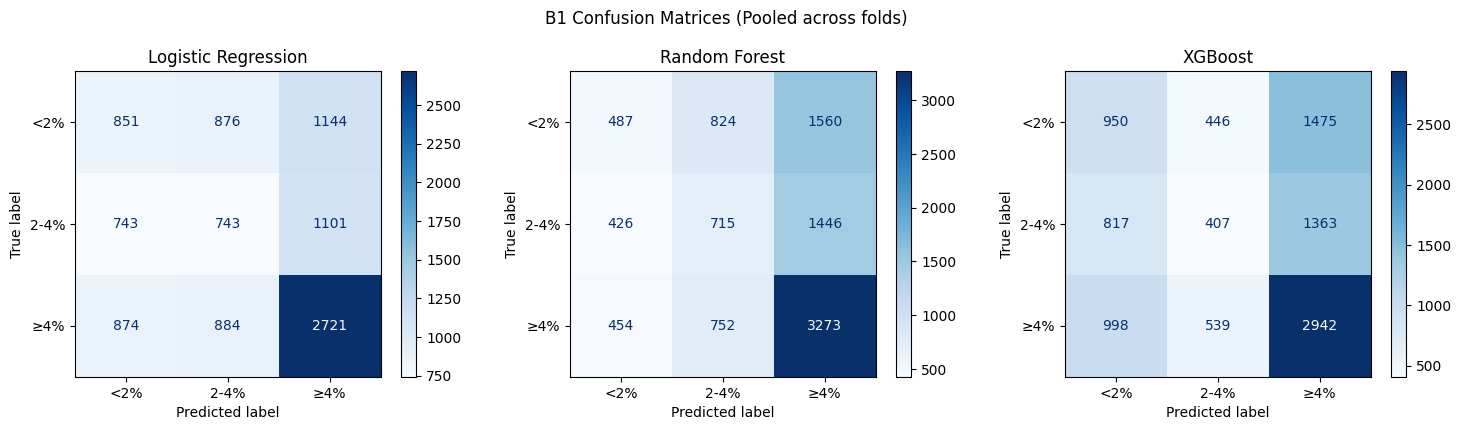

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, r) in zip(axes, [("Logistic Regression", lr_clf),
                                 ("Random Forest", rf_clf),
                                 ("XGBoost", xgb_clf)]):
    true = np.array(r["true"])
    preds = np.array(r["preds"])
    ConfusionMatrixDisplay.from_predictions(true, preds, ax=ax, cmap="Blues",
                                            display_labels=["<2%", "2-4%", "≥4%"])
    ax.set_title(name)

plt.suptitle("B1 Confusion Matrices (Pooled across folds)", y=1.02)
plt.tight_layout()
plt.show()

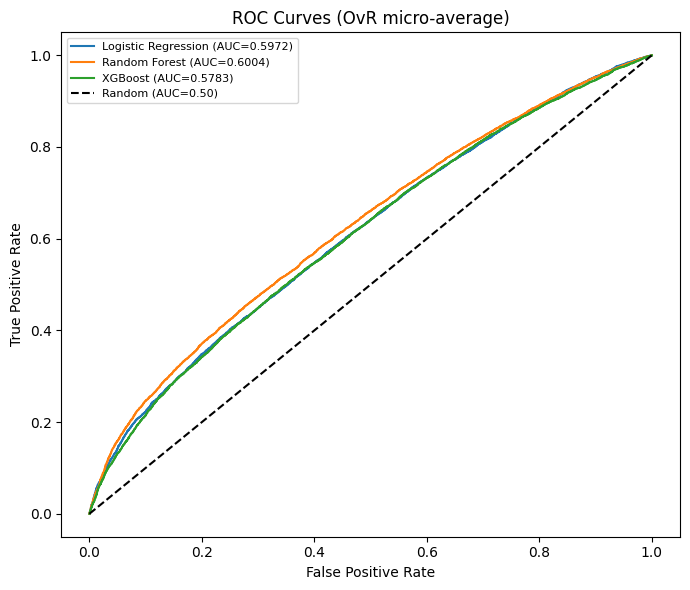

In [14]:
# 3-class ROC: use roc_auc_score with OvR
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve

classes = [0, 1, 2]
labels = ["Low (<2%)", "Moderate (2-4%)", "Strong (≥4%)"]
fig, ax = plt.subplots(figsize=(7, 6))

for name, r in [("Logistic Regression", lr_clf),
                ("Random Forest", rf_clf),
                ("XGBoost", xgb_clf)]:
    y_true_bin = label_binarize(np.array(r["true"]), classes=classes)
    y_score = np.array(r["probs"])
    auc_val = roc_auc_score(np.array(r["true"]), y_score, multi_class='ovr', average='weighted')

    # Plot the OvR micro-average ROC
    fpr, tpr, _ = roc_curve(y_true_bin.ravel(), y_score.ravel())
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc_val:.4f})")

ax.plot([0, 1], [0, 1], "k--", label="Random (AUC=0.50)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves (OvR micro-average)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


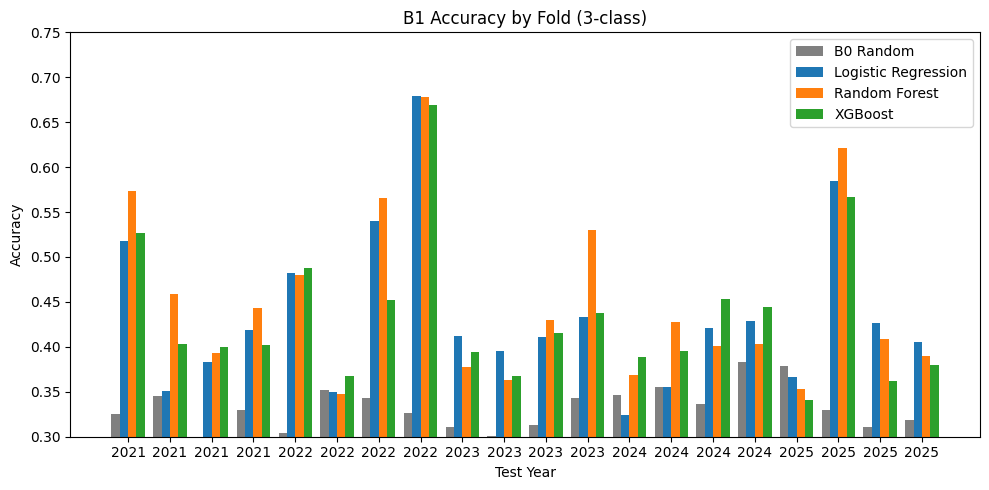

In [15]:
fold_years = [f["test_year"] for f in folds_data]
x = np.arange(len(fold_years))
width = 0.2

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width, b0_clf["fold_acc"], width, label="B0 Random", color="gray")
ax.bar(x, lr_clf["fold_acc"], width, label="Logistic Regression")
ax.bar(x + width, rf_clf["fold_acc"], width, label="Random Forest")
ax.bar(x + 2*width, xgb_clf["fold_acc"], width, label="XGBoost")

ax.set_xticks(x + width/2)
ax.set_xticklabels(fold_years)
ax.set_xlabel("Test Year")
ax.set_ylabel("Accuracy")
ax.set_title("B1 Accuracy by Fold (3-class)")
ax.legend()
ax.set_ylim(0.3, 0.75)
plt.tight_layout()
plt.show()

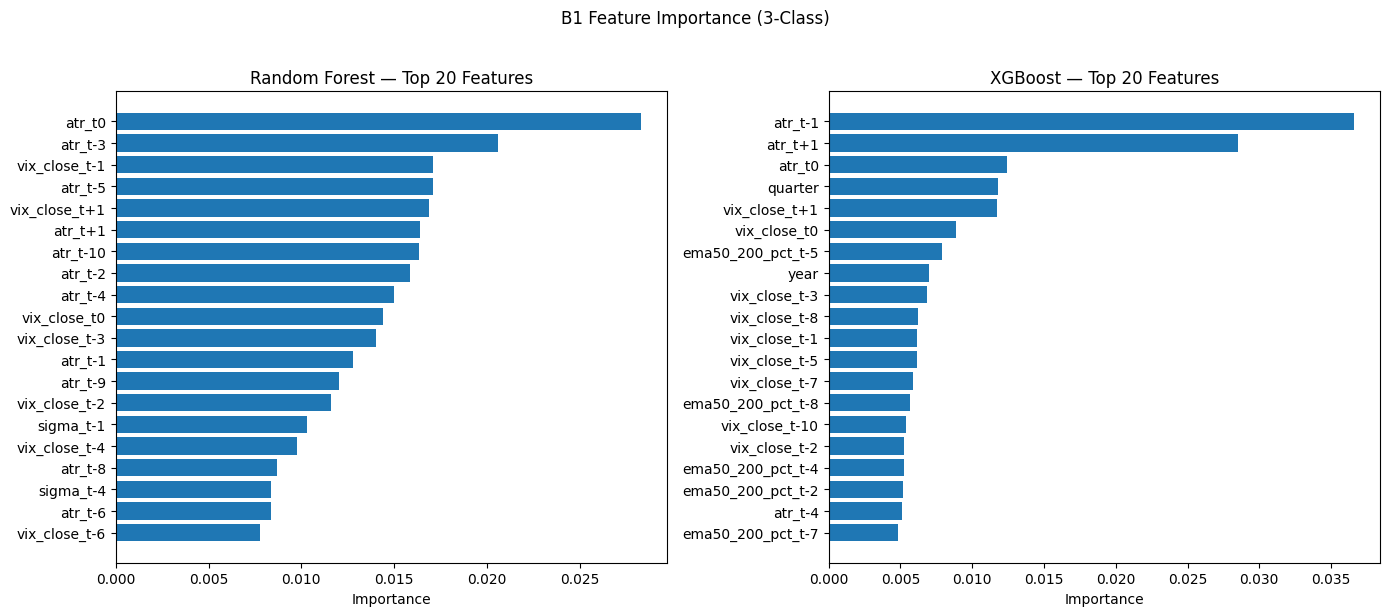

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Random Forest
rf_imp = rf_clf_model.feature_importances_
rf_top_idx = np.argsort(rf_imp)[-20:]
axes[0].barh(np.array(feature_cols)[rf_top_idx], rf_imp[rf_top_idx])
axes[0].set_title("Random Forest — Top 20 Features")
axes[0].set_xlabel("Importance")

# XGBoost
xgb_imp = xgb_clf_model.feature_importances_
xgb_top_idx = np.argsort(xgb_imp)[-20:]
axes[1].barh(np.array(feature_cols)[xgb_top_idx], xgb_imp[xgb_top_idx])
axes[1].set_title("XGBoost — Top 20 Features")
axes[1].set_xlabel("Importance")

plt.suptitle("B1 Feature Importance (3-Class)", y=1.02)
plt.tight_layout()
plt.show()

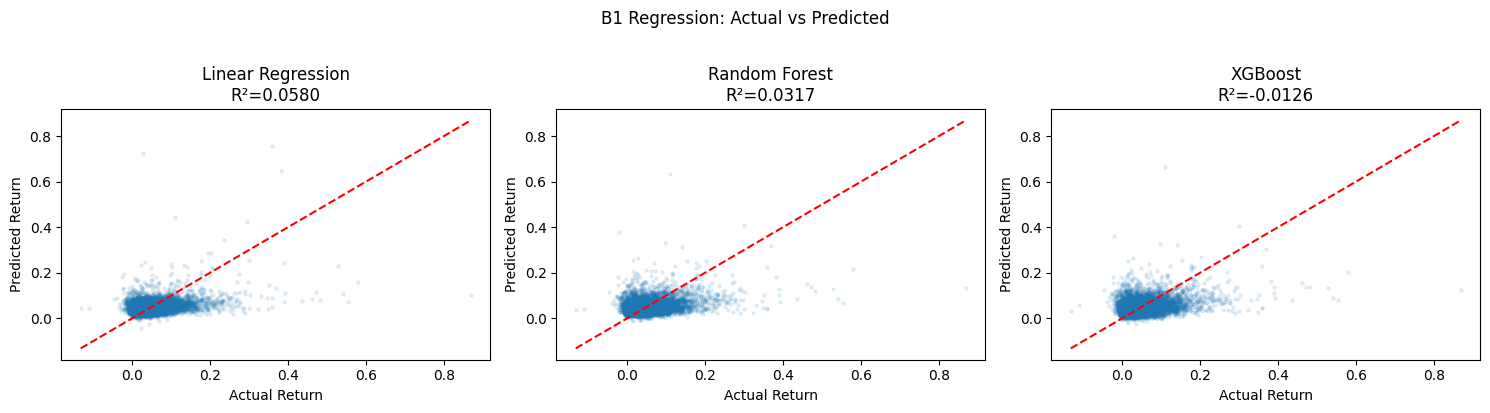

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, r) in zip(axes, [("Linear Regression", linreg),
                                  ("Random Forest", rf_reg),
                                  ("XGBoost", xgb_reg)]):
    true = np.array(r["true"])
    preds = np.array(r["preds"])
    ax.scatter(true, preds, alpha=0.1, s=5)
    ax.plot([true.min(), true.max()], [true.min(), true.max()], "r--")
    ax.set_xlabel("Actual Return")
    ax.set_ylabel("Predicted Return")
    ax.set_title(f"{name}\nR²={r2_score(true, preds):.4f}")

plt.suptitle("B1 Regression: Actual vs Predicted", y=1.02)
plt.tight_layout()
plt.show()

In [18]:
os.makedirs("models", exist_ok=True)

for name, model in [("lr_clf", lr_model), ("linreg", linreg_model),
                     ("rf_clf", rf_clf_model), ("rf_reg", rf_reg_model),
                     ("xgb_clf", xgb_clf_model), ("xgb_reg", xgb_reg_model)]:
    joblib.dump(model, f"models/b1_{name}.pkl")
    print(f"Saved models/b1_{name}.pkl")

with open("models/b1_results.pkl", "wb") as f:
    pickle.dump({
        "clf": {"B0 Random": b0_clf, "Logistic Regression": lr_clf,
                "Random Forest": rf_clf, "XGBoost": xgb_clf},
        "reg": {"B0 Mean": b0_reg, "Linear Regression": linreg,
                "Random Forest": rf_reg, "XGBoost": xgb_reg},
    }, f)
print("Saved models/b1_results.pkl")

Saved models/b1_lr_clf.pkl
Saved models/b1_linreg.pkl
Saved models/b1_rf_clf.pkl
Saved models/b1_rf_reg.pkl
Saved models/b1_xgb_clf.pkl
Saved models/b1_xgb_reg.pkl
Saved models/b1_results.pkl
